In [252]:
import numpy as np
import math
import scipy.constants as const
import matplotlib.pyplot as plt

In [253]:
# # Guardo los datos generados

# # Suponiendo que 'data' es un array de NumPy que ya contiene tus datos
# data_filtrados = np.array([fila for fila in data if fila[-1] != 0.0])

# # Creo el archivo para guardar losd datos
# np.savetxt('Recombinacion_data.csv', data_filtrados,  fmt=['%d', '%.5f', '%d', '%d', '%f', '%.6e', '%.1f'],
#            header='paso, tiempo simulacion, x, y, probabilidad recombinacion, velocidad, funcion a trozos', comments='', delimiter=', ')

In [254]:
temperature = 300
atom_size = 0.25e-9
E_m = 0.89

k_b_ev = const.physical_constants['Boltzmann constant in eV/K'][0]
gamma_drift = 8
paso_temp = 10/10000
espesor = 10e-9
V_inicial = 0
t_0 = 1e13
E_field = np.linspace(0, 3/(10e-9), 10000)
senoh = np.zeros(10000)
oxigen_velocity = np.zeros(10000)
desplazamiento = np.zeros(10000)

In [255]:
for i in range(0, 10000):
    senoh[i] = math.sinh((atom_size * E_field[i] * gamma_drift) / (2 * k_b_ev * temperature))
    exp_velocity = math.exp(-E_m / (k_b_ev * temperature))

    # el t_0 es el valor de 1/t_0 que lo pongo directamente y "factor" es algo que introduzco a mano para ajustar la velocidad
    oxigen_velocity[i] = 2 * t_0 * atom_size * (senoh[i] * exp_velocity)

    desplazamiento[i] = np.round((oxigen_velocity[i] * paso_temp) / atom_size)

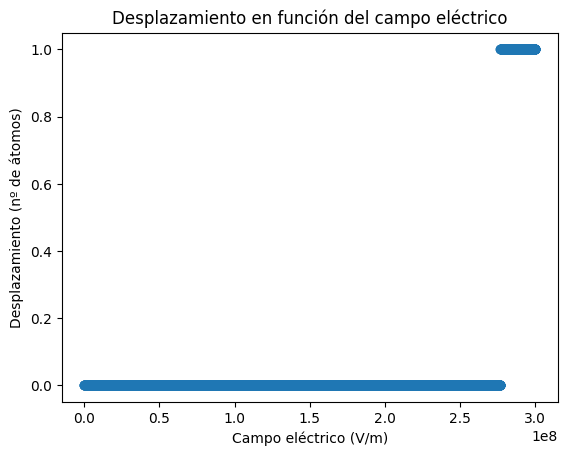

In [256]:
# represento los valores del seno hiperbolico en funcion del tiempo que va desde 0 a 10 s con un paso de 10/10000
plt.scatter(E_field, desplazamiento)
plt.xlabel('Campo eléctrico (V/m)')
plt.ylabel('Desplazamiento (nº de átomos)')
plt.title('Desplazamiento en función del campo eléctrico')
plt.show()